SVD 推荐系统演示
用户-电影评分矩阵 (0 = 未评分):
[[5 4 0 1]
 [4 0 3 2]
 [0 5 4 0]
 [3 3 5 4]
 [1 0 2 5]]

奇异值: [11.771  5.674  4.898  2.5  ]

秩为 2 的近似矩阵 (填补了缺失值):
[[ 2.3  3.8  2.7  0.9]
 [ 2.4  0.9  2.6  3.2]
 [ 2.   4.9  2.5 -0.3]
 [ 3.8  3.   4.3  4. ]
 [ 2.2 -0.7  2.3  4.1]]

预测的评分 (填补0的位置):
用户 1 → 电影 3: 预测评分 = 2.7
用户 2 → 电影 2: 预测评分 = 0.9
用户 3 → 电影 1: 预测评分 = 2.0
用户 3 → 电影 4: 预测评分 = -0.3
用户 5 → 电影 2: 预测评分 = -0.7


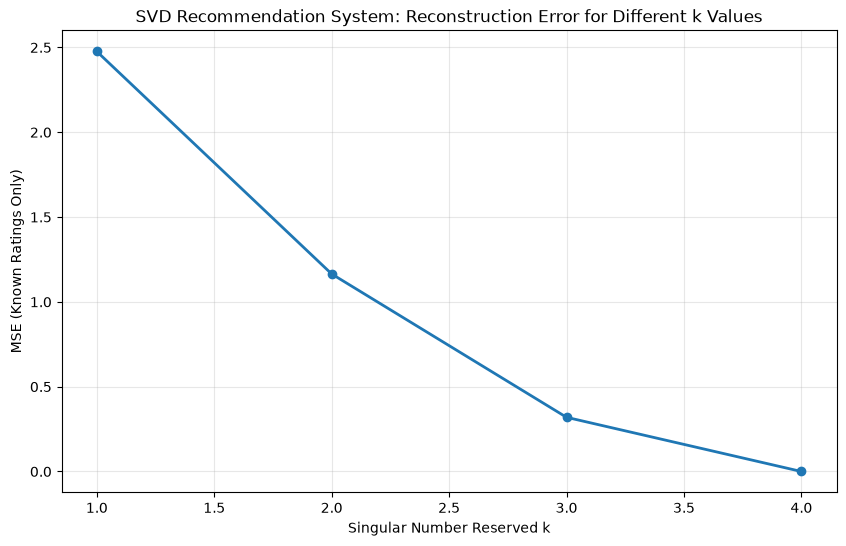


推荐结果 (基于预测评分)
用户 1: 推荐电影 3 (预测评分 0.0)
用户 2: 推荐电影 2 (预测评分 0.0)
用户 3: 推荐电影 4 (预测评分 0.0)
用户 5: 推荐电影 2 (预测评分 0.0)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 创建一个 5x4 的用户-物品评分矩阵 ----
# 5个用户，4部电影，评分 1-5
np.random.seed(42)
A = np.array([
    [5, 4, 0, 1],
    [4, 0, 3, 2],
    [0, 5, 4, 0],
    [3, 3, 5, 4],
    [1, 0, 2, 5]
])
print("=" * 60)
print("SVD 推荐系统演示")
print("=" * 60)
print("用户-电影评分矩阵 (0 = 未评分):")
print(A)

# ---- SVD 分解 ----
U, S, Vt = np.linalg.svd(A, full_matrices=False)
print(f"\n奇异值: {S.round(3)}")

# ---- 用低秩近似填补缺失值 ----
# 选择 k = 2 (保留前2个奇异值)
k = 2
A_k = (U[:, :k] * S[:k]) @ Vt[:k, :]
print(f"\n秩为 {k} 的近似矩阵 (填补了缺失值):")
print(A_k.round(1))

# ---- 只看预测的评分 ----
print("\n" + "=" * 60)
print("预测的评分 (填补0的位置):")
print("=" * 60)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if A[i, j] == 0:
            print(f"用户 {i+1} → 电影 {j+1}: 预测评分 = {A_k[i, j]:.1f}")

# ---- 用不同 k 值的重构误差 ----
k_values = range(1, min(A.shape) + 1)
errors = []
for k in k_values:
    A_k = (U[:, :k] * S[:k]) @ Vt[:k, :]
    # 只计算已知评分的误差
    mask = A > 0
    mse = np.mean((A[mask] - A_k[mask])**2)
    errors.append(mse)

plt.figure(figsize=(10, 6))
plt.plot(k_values, errors, 'o-', linewidth=2)
# plt.xlabel('保留的奇异值数量 k')
plt.xlabel('Singular Number Reserved k')
# plt.ylabel('MSE (仅已知评分)')
plt.ylabel('MSE (Known Ratings Only)')
# plt.title('SVD 推荐系统：不同 k 值的重构误差')
plt.title('SVD Recommendation System: Reconstruction Error for Different k Values')
plt.grid(alpha=0.3)
plt.show()

# ---- 推荐 ----
print("\n" + "=" * 60)
print("推荐结果 (基于预测评分)")
print("=" * 60)
for i in range(A.shape[0]):
    # 用户 i 未看过的电影
    unseen = np.where(A[i, :] == 0)[0]
    if len(unseen) > 0:
        predictions = A_k[i, unseen]
        best_movie = unseen[np.argmax(predictions)]
        print(f"用户 {i+1}: 推荐电影 {best_movie+1} (预测评分 {A_k[i, best_movie]:.1f})")